<a href="https://colab.research.google.com/github/AlaKh09/Mentalist/blob/Notebook/mentalist_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mentalist — Segmentation des patients et prédiction de la réadmission à 30 jours chez les patients diabétiques
*Lab de préparation des données, clustering et classification — dataset Diabetes 130-US Hospitals*

**Dataset :** 101 766 séjours hospitaliers de patients diabétiques (1999–2008) + `IDS_mapping.csv` (dictionnaire pour décoder les identifiants d'admission et de sortie).

**Plan du notebook :** 0. État de l'art → 1. Objectifs (BO / DSO) → 2. Chargement → 3. Exploration et visualisation → 4. Nettoyage et transformation (chaque choix justifié) → 5. Clustering → 6. Classification → 7. Conclusions.


## 0. État de l'art


*Objectif de cette section : situer le travail par rapport à ce qui existe déjà, pour justifier nos choix (modèles, métriques) et disposer d'un repère réaliste de performance.*

**Origine des données.** Le dataset est un extrait de 10 ans (1999–2008) de soins cliniques dans 130 hôpitaux américains (base Health Facts). Il a été analysé par Strack et al. (2014), qui ont étudié le lien entre la **mesure de l'HbA1c** à l'hôpital et la réadmission précoce, à l'aide d'une **régression logistique multivariée**. Ils rapportent que l'HbA1c n'était mesurée que dans 18,4 % des séjours et que son lien avec la réadmission dépend du diagnostic principal. Le dataset a ensuite été déposé sur le dépôt UCI Machine Learning Repository.

**Pratiques courantes sur ce type de problème** *(synthèse générale, à vérifier avec des sources avant citation)*
* **Modèles :** régression logistique (référence interprétable), Random Forest et gradient boosting ; l'apprentissage profond apporte en général peu sur ce type de données tabulaires.
* **Performance :** la prédiction de la réadmission est réputée difficile ; les AUC rapportés se situent le plus souvent autour de 0,6 à 0,7, y compris pour des scores cliniques comme l'indice LACE, car des facteurs décisifs (soutien social, observance, soins après la sortie) ne figurent pas dans les données.
* **Contexte réglementaire :** aux États-Unis, le programme Medicare de réduction des réadmissions (HRRP) pénalise les hôpitaux pour des réadmissions excessives dans certaines pathologies, ce qui explique l'intérêt financier du sujet.

**Pièges fréquents** : patients répétés qui provoquent une fuite entre train et test, conservation des patients décédés ou en hospice (non réadmissibles), usage de l'accuracy malgré le déséquilibre des classes, et regroupement insuffisant des codes diagnostics.

**Positionnement de Reditus**
* On évite les trois premiers pièges (un séjour par patient, exclusion décès/hospice, métriques adaptées au déséquilibre).
* On **combine segmentation et prédiction** : la segmentation explique *qui* sont les patients, la classification prédit *qui reviendra*, ce que les études centrées sur un seul modèle de prédiction font rarement.
* Repère de performance attendu : une AUC proche de 0,65 serait cohérente avec les ordres de grandeur de la littérature.

**Références**
* Strack B., DeShazo J. P., Gennings C., Olmo J. L., Ventura S., Cios K. J., Clore J. N. (2014). *Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records.* BioMed Research International, 2014, 781670. doi:10.1155/2014/781670
* Strack B. et al. (2014). *Diabetes 130-US Hospitals for Years 1999–2008* [dataset]. UCI Machine Learning Repository.
* À ajouter après vérification : van Walraven C. et al. (2010), indice LACE, *CMAJ* ; documentation du programme Medicare HRRP.

## 1. De l'objectif métier (BO) à l'objectif Data Science (DSO)

| | Objectif métier (BO) | Objectif Data Science (DSO) |
|---|---|---|
| **Classification** | Réduire les réadmissions évitables à 30 jours (coûts + pénalités Medicare + préjudice pour le patient) en ciblant le suivi sur les patients à haut risque | Prédire `readmitted == '<30'` à la sortie. Succès = bon **recall / PR-AUC** sur la classe minoritaire (~11 % de positifs, ~9 % une fois un seul séjour gardé par patient) |
| **Clustering** | Personnaliser les parcours de soins selon le type de patient | Trouver 3 à 6 segments de patients interprétables (silhouette, Davies-Bouldin) et comparer leur risque de réadmission |

### 1.1 Compréhension métier — BO1 : Réduire les réadmissions évitables à 30 jours

| Élément | Description |
|---|---|
| **Contexte** | Le diabète est une maladie chronique aux complications fréquentes. Les hôpitaux réadmettent régulièrement des patients diabétiques peu après leur sortie. |
| **Problème métier** | Une réadmission sous 30 jours signale souvent une guérison incomplète, une sortie trop précoce ou un suivi insuffisant. Elle est coûteuse pour l'hôpital (lits, personnel, pénalités financières dans de nombreux systèmes d'assurance santé comme le programme de réadmission de Medicare) et néfaste pour le patient. |
| **Parties prenantes** | Direction de l'hôpital (coûts, indicateurs qualité), médecins et infirmiers (décisions de soin), coordinateurs de soins (suivi), patients. |
| **Objectif métier** | Identifier **à la sortie** les patients les plus susceptibles de revenir sous 30 jours, afin de concentrer les ressources de suivi limitées (appel, rendez-vous précoce, revue des médicaments) sur ceux qui en ont le plus besoin. |
| **Critères de succès métier** | Moins de réadmissions à 30 jours ; effort de suivi concentré sur une petite part des patients (par ex. les 20 % de scores de risque les plus élevés capturent une grande part des réadmissions). |
| **Tâche Data Science** | Classification binaire de `readmitted == '<30'`. |
| **Contraintes et risques** | Fort déséquilibre des classes (~9–11 % de positifs) ; manquer un patient à haut risque coûte plus cher qu'un appel inutile ; les prédictions sont une aide au tri, pas une décision clinique ; l'équité selon l'âge, l'origine et le genre doit être surveillée. |

### 1.2 Compréhension métier — BO2 : Personnaliser les soins grâce à la segmentation des patients

| Élément | Description |
|---|---|
| **Contexte** | Les patients diabétiques hospitalisés ne forment pas une population homogène : un jeune patient en séjour programmé court et un patient âgé avec de nombreuses comorbidités et des admissions répétées n'ont pas les mêmes besoins. |
| **Problème métier** | Un protocole de sortie et de suivi identique pour tous gaspille des ressources sur les patients à faible risque et sert mal les patients complexes. L'hôpital n'a pas de typologie claire de ses patients diabétiques. |
| **Parties prenantes** | Responsables de parcours de soins, chefs de service, planificateurs de l'hôpital et direction financière (allocation des ressources). |
| **Objectif métier** | Construire un petit nombre de **profils de patients interprétables** et concevoir un parcours de soins adapté à chacun (par ex. suivi pharmaceutique pour les patients dont le traitement change souvent, gestion de cas pour les usagers fréquents des urgences). |
| **Critères de succès métier** | 3 à 6 segments compréhensibles par les cliniciens, assez grands pour être actionnables, et différents par leurs besoins et leur risque de réadmission. |
| **Tâche Data Science** | Clustering non supervisé (K-Means) sur des variables cliniques et d'utilisation des soins, puis profilage de chaque segment, y compris son taux de réadmission (utilisé uniquement *après* le clustering, pas pour le construire). |
| **Contraintes et risques** | Pas de vérité terrain : la qualité se juge par la silhouette / Davies-Bouldin et par l'interprétabilité clinique ; les segments peuvent se chevaucher ; le résultat dépend des variables choisies et de la mise à l'échelle. |

**Lien entre les deux objectifs :** le BO2 explique *qui* sont les patients, le BO1 prédit *qui reviendra*. Ensemble, ils permettent d'adapter le parcours par segment et de prioriser, au sein de chaque segment, selon le score de risque.

# 2. Data Understanding

## 2.1 Présentation du dataset

Le dataset utilisé est :

**Diabetes 130-US Hospitals for Years 1999–2008**

Il contient des informations relatives aux patients diabétiques,
leurs séjours hospitaliers, leurs diagnostics, leurs traitements,
leurs examens médicaux et leurs précédentes utilisations des services
de santé.

Le dataset contient :

- 101 766 séjours hospitaliers
- 50 variables
- Des variables numériques
- Des variables catégorielles
- Des variables médicales
- Des variables concernant les médicaments
- Des informations sur les admissions et sorties
- Une variable cible concernant la réadmission

# Importation des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage plus lisible
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

In [14]:
# Importation des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage plus lisible
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2.2 Chargement du dataset

Nous allons maintenant charger le fichier `diabetic_data.csv`.
Le fichier peut être importé directement depuis
l'ordinateur.

In [15]:
import pandas as pd

df = pd.read_csv("diabetic_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [16]:
# Dimensions du dataset

print("Number of rows :", df.shape[0])
print("Number of columns :", df.shape[1])

Number of rows : 101766
Number of columns : 50


## 2.3 Aperçu du dataset

Nous allons afficher les premières lignes du dataset afin d'avoir une
première idée sur la structure des données.

In [ ]:
# Affichage des 5 premières lignes

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# Affichage des 5 dernières lignes

df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,MC,?,51,0,16,0,0,0,250.13,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,MC,?,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,MC,?,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,?,?,13,3,3,0,0,0,530,530,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO


## 2.4 Structure du dataset

Nous allons maintenant examiner :

- Le nombre de lignes et de colonnes
- Les noms des variables
- Le type de chaque variable
- La présence éventuelle de valeurs manquantes

In [ ]:
# Informations générales sur le dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
# Liste des variables

print("Nombre de variables :", len(df.columns))
print("\nListe des variables :\n")

for i, column in enumerate(df.columns, 1):
    print(i, "→", column)

Nombre de variables : 50

Liste des variables :

1 → encounter_id
2 → patient_nbr
3 → race
4 → gender
5 → age
6 → weight
7 → admission_type_id
8 → discharge_disposition_id
9 → admission_source_id
10 → time_in_hospital
11 → payer_code
12 → medical_specialty
13 → num_lab_procedures
14 → num_procedures
15 → num_medications
16 → number_outpatient
17 → number_emergency
18 → number_inpatient
19 → diag_1
20 → diag_2
21 → diag_3
22 → number_diagnoses
23 → max_glu_serum
24 → A1Cresult
25 → metformin
26 → repaglinide
27 → nateglinide
28 → chlorpropamide
29 → glimepiride
30 → acetohexamide
31 → glipizide
32 → glyburide
33 → tolbutamide
34 → pioglitazone
35 → rosiglitazone
36 → acarbose
37 → miglitol
38 → troglitazone
39 → tolazamide
40 → examide
41 → citoglipton
42 → insulin
43 → glyburide-metformin
44 → glipizide-metformin
45 → glimepiride-pioglitazone
46 → metformin-rosiglitazone
47 → metformin-pioglitazone
48 → change
49 → diabetesMed
50 → readmitted


## 2.5 Catégorisation des variables

Les variables du dataset peuvent être regroupées en plusieurs catégories.

### Variables d'identification

- `encounter_id`
- `patient_nbr`

### Variables démographiques

- `race`
- `gender`
- `age`
- `weight`

### Variables concernant l'hospitalisation

- `admission_type_id`
- `discharge_disposition_id`
- `admission_source_id`
- `time_in_hospital`

### Variables concernant l'utilisation des services de santé

- `number_outpatient`
- `number_emergency`
- `number_inpatient`

### Variables médicales

- `diag_1`
- `diag_2`
- `diag_3`
- `number_diagnoses`

### Variables de laboratoire

- `num_lab_procedures`
- `num_procedures`
- `max_glu_serum`
- `A1Cresult`

### Variables concernant les médicaments

Le dataset contient plusieurs variables décrivant les traitements
médicamenteux du patient, notamment l'insuline et différents traitements
du diabète.

### Variable cible

- `readmitted`

In [ ]:
# Types des variables
# Types des variables
dtypes = df.dtypes.reset_index()
dtypes.columns = ['Variable', 'Type']

# 7 lignes par colonne
n = 7
columns = []

for i in range(0, len(dtypes), n):
    part = dtypes.iloc[i:i+n].reset_index(drop=True)
    part.columns = [f'Variable', f'Type']
    columns.append(part)

# Afficher les blocs côte à côte
result = pd.concat(columns, axis=1)

display(result)

,Variable,Type,Variable,Type,Variable,Type,Variable,Type,Variable,Type,Variable,Type,Variable,Type,Variable,Type
0,encounter_id,int64,discharge_disposition_id,int64,num_medications,int64,number_diagnoses,int64,glimepiride,object,acarbose,object,glyburide-metformin,object,readmitted,object
1,patient_nbr,int64,admission_source_id,int64,number_outpatient,int64,max_glu_serum,object,acetohexamide,object,miglitol,object,glipizide-metformin,object,NaN,NaN
2,race,object,time_in_hospital,int64,number_emergency,int64,A1Cresult,object,glipizide,object,troglitazone,object,glimepiride-pioglitazone,object,NaN,NaN
3,gender,object,payer_code,object,number_inpatient,int64,metformin,object,glyburide,object,tolazamide,object,metformin-rosiglitazone,object,NaN,NaN
4,age,object,medical_specialty,object,diag_1,object,repaglinide,object,tolbutamide,object,examide,object,metformin-pioglitazone,object,NaN,NaN
5,weight,object,num_lab_procedures,int64,diag_2,object,nateglinide,object,pioglitazone,object,citoglipton,object,change,object,NaN,NaN
6,admission_type_id,int64,num_procedures,int64,diag_3,object,chlorpropamide,object,rosiglitazone,object,insulin,object,diabetesMed,object,NaN,NaN


## 2.6 Analyse statistique des variables numériques

Nous allons utiliser les statistiques descriptives afin d'analyser
les variables numériques.

Les principales statistiques étudiées sont :

- La moyenne
- L'écart-type
- Le minimum
- Le maximum
- Les quartiles

In [ ]:
# Statistiques descriptives des variables numériques

df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


## 2.7 Analyse des valeurs manquantes

La qualité des données constitue une étape importante de la Data Preparation.

Nous allons rechercher les valeurs manquantes présentes dans le dataset.

Il faut également vérifier la présence du caractère `?`, car certaines
valeurs manquantes du dataset sont représentées sous cette forme.

In [ ]:
# Valeurs manquantes NaN

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print("Valeurs manquantes :")
print(missing_values.sort_values(ascending=False))

Valeurs manquantes :
max_glu_serum    96420
A1Cresult        84748
dtype: int64


In [ ]:
# Recherche des valeurs représentées par "?"

question_marks = (df == "?").sum()

question_marks = question_marks[question_marks > 0]

print("Valeurs '?' dans le dataset :")
print(question_marks.sort_values(ascending=False))

Valeurs '?' dans le dataset :
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [ ]:
# Pourcentage de "?" par variable

question_percentage = ((df == "?").mean() * 100)

question_percentage = question_percentage[
    question_percentage > 0
].sort_values(ascending=False)

question_percentage

,0
weight,96.858479
medical_specialty,49.082208
payer_code,39.557416
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636


### Observation — Data Quality

L'analyse montre que certaines variables contiennent des valeurs manquantes
représentées par le caractère `?`.

Ces valeurs devront être traitées pendant l'étape de Data Preparation.

Nous ne devons pas supprimer automatiquement ces variables. Leur taux de
valeurs manquantes devra d'abord être analysé afin de choisir une stratégie
appropriée.

## 2.8 Analyse de la variable cible

La variable `readmitted` représente le statut de réadmission du patient.

Elle contient trois catégories :

- `<30` : réadmission dans les 30 jours
- `>30` : réadmission après plus de 30 jours
- `NO` : aucune réadmission

In [ ]:
# Distribution de la variable cible

print(df["readmitted"].value_counts())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [ ]:
# Pourcentage de chaque classe

print(
    df["readmitted"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


### Observation

La distribution de `readmitted` montre que les trois catégories ne sont
pas représentées de manière uniforme.

La classe `<30`, qui correspond à notre problème de classification,
est minoritaire.

Cette situation devra être prise en compte lors de la construction du
modèle de classification.

L'accuracy seule ne sera donc pas suffisante pour évaluer correctement
le modèle. Des métriques adaptées au déséquilibre des classes seront
utilisées, notamment le recall et la PR-AUC.

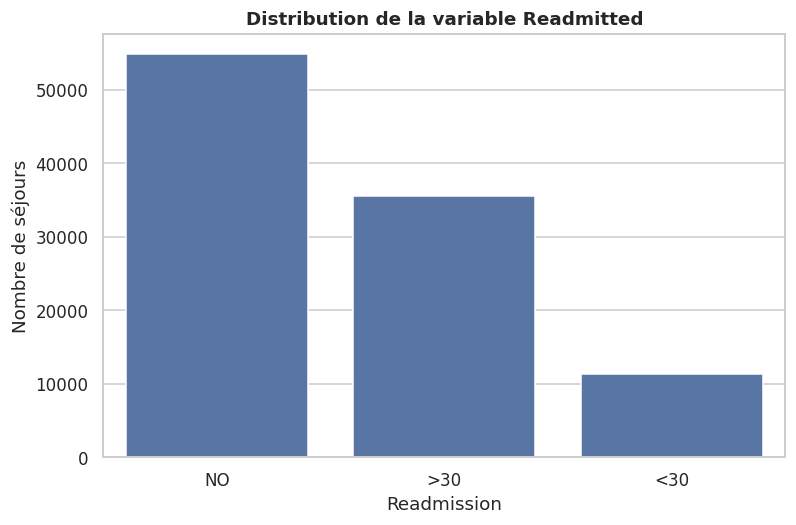

In [ ]:
# Visualisation de la variable cible

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="readmitted"
)

plt.title("Distribution de la variable Readmitted")
plt.xlabel("Readmission")
plt.ylabel("Nombre de séjours")

plt.show()

## 2.9 Analyse des variables numériques importantes

Nous allons analyser plusieurs variables numériques liées au séjour
hospitalier et à l'utilisation des services de santé :

- `time_in_hospital`
- `num_lab_procedures`
- `num_procedures`
- `num_medications`
- `number_outpatient`
- `number_emergency`
- `number_inpatient`
- `number_diagnoses`

In [ ]:
numeric_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


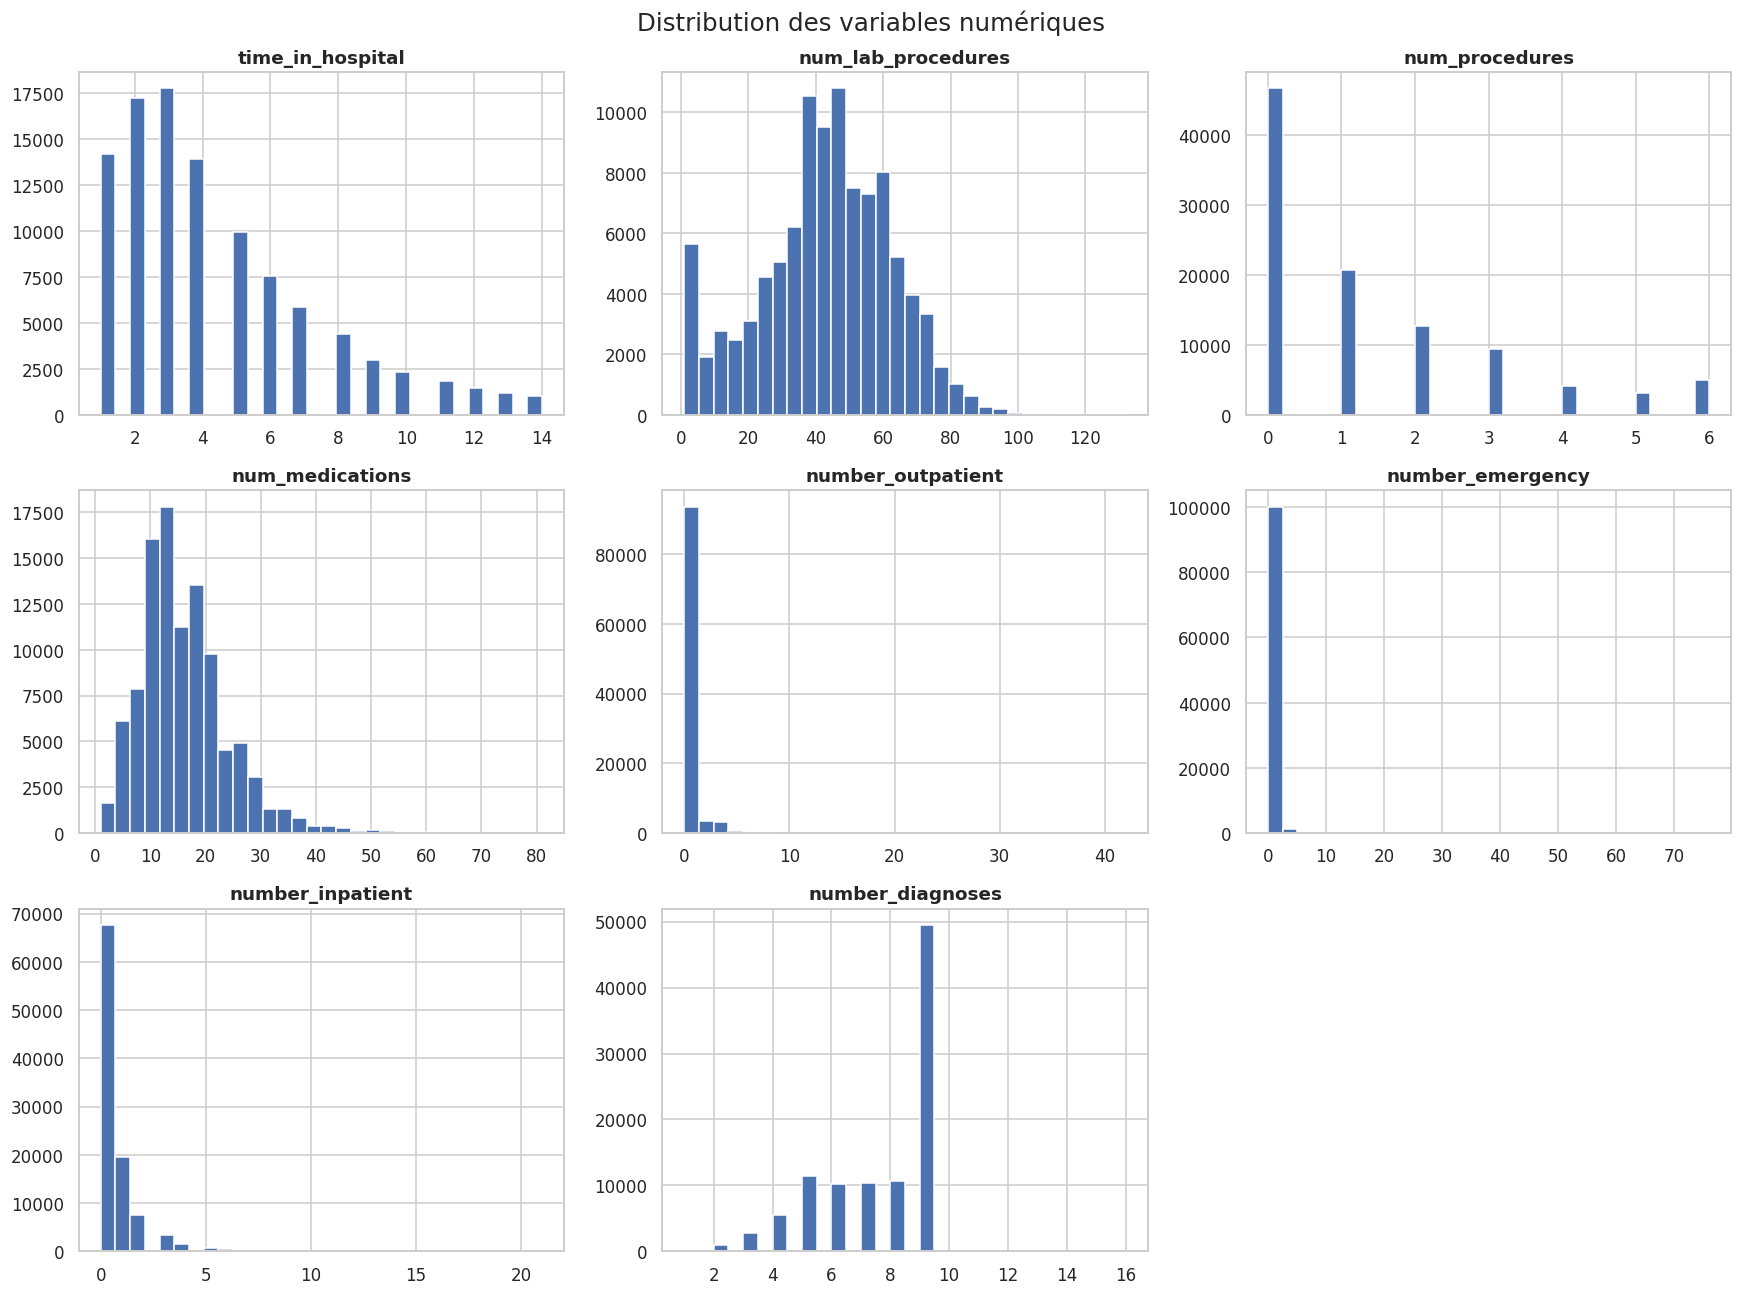

In [ ]:
# Histogrammes des variables numériques

df[numeric_columns].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle(
    "Distribution des variables numériques",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Observation

Les distributions des variables numériques ne sont pas toutes similaires.

Certaines variables présentent une forte concentration de valeurs faibles
et quelques valeurs élevées.

Cela peut indiquer une asymétrie de distribution et la présence potentielle
de valeurs extrêmes.

Ces observations seront prises en compte lors de l'étape de Data
Preparation.

## 2.10 Analyse des valeurs aberrantes — Outliers

Les valeurs aberrantes doivent être étudiées avant de décider de les
supprimer ou de les transformer.

Nous allons utiliser des boxplots pour visualiser les valeurs extrêmes
des variables numériques.

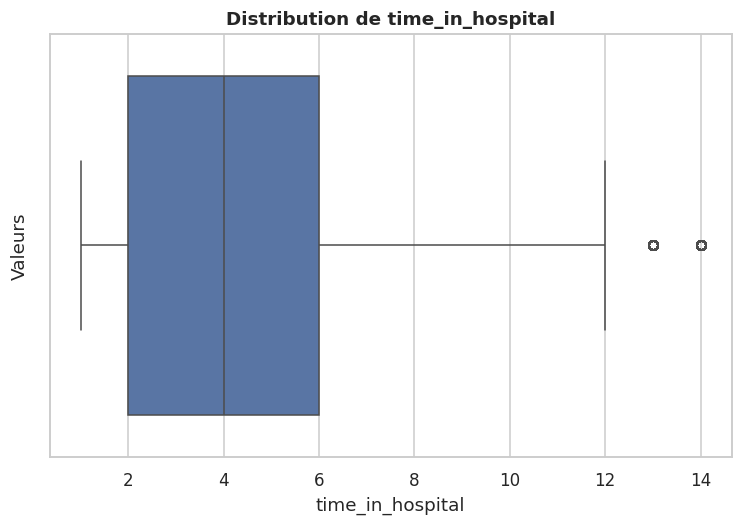

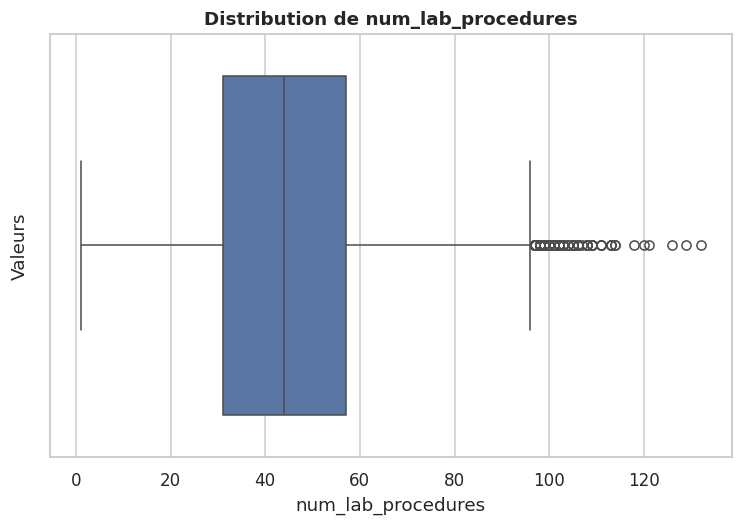

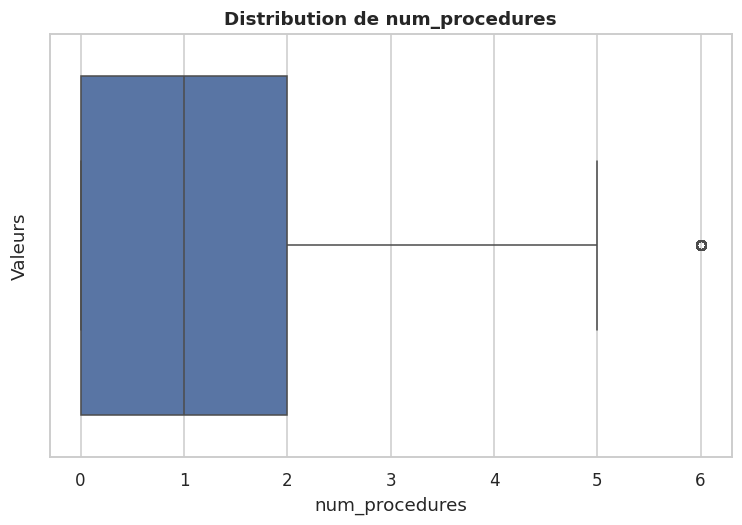

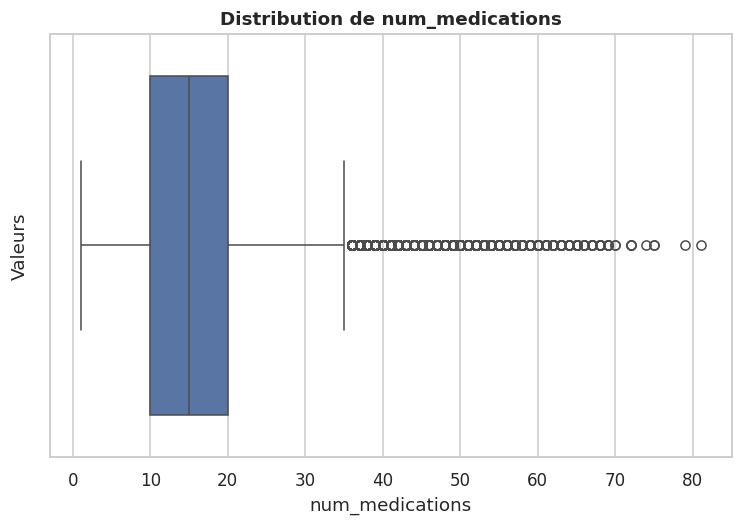

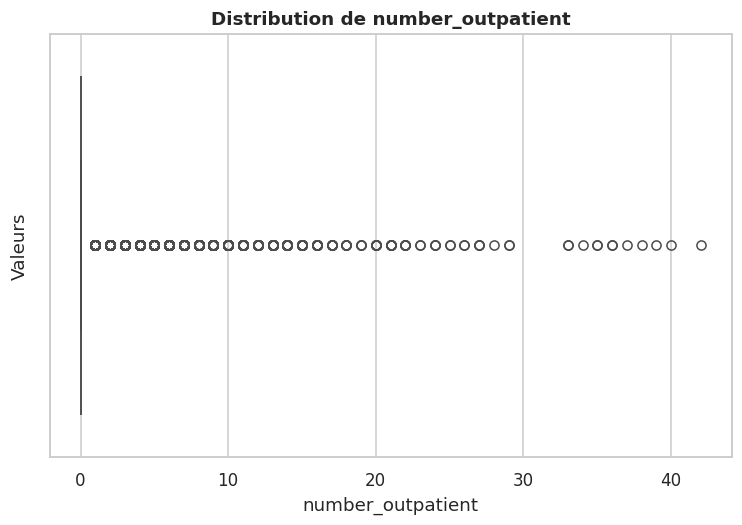

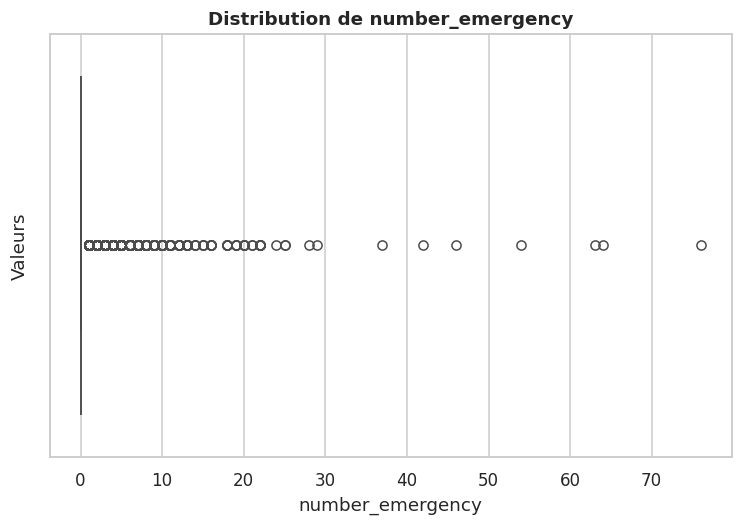

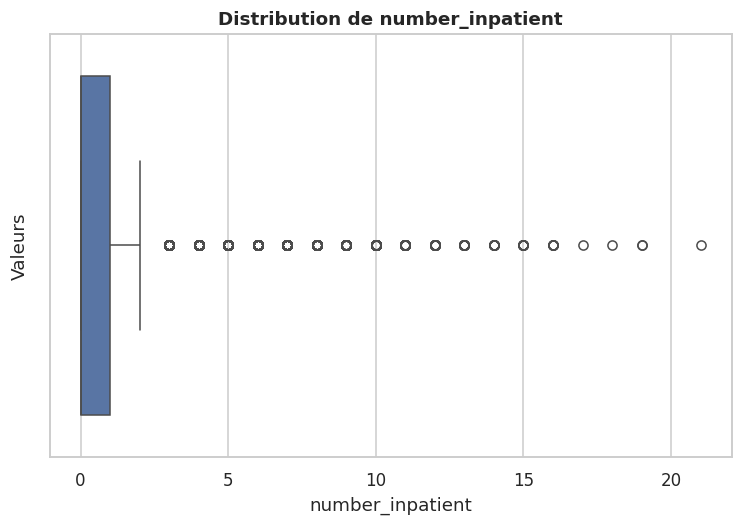

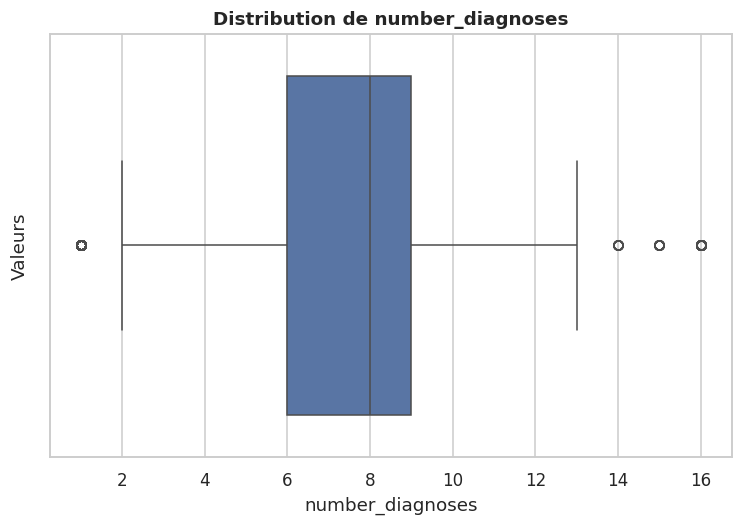

In [ ]:

 # Visualisation des variables numériques

for column in numeric_columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f"Distribution de {column}")
    plt.xlabel(column)
    plt.ylabel("Valeurs")

    plt.show()

### Observation

Les boxplots permettent d'identifier les observations situées très loin
de la majorité des valeurs.

Cependant, une valeur extrême dans un contexte hospitalier n'est pas
nécessairement une erreur.

Elle peut correspondre à un patient ayant utilisé fréquemment les services
de santé.

Les valeurs aberrantes devront donc être analysées avant toute suppression.

## 2.11 Matrice de corrélation

Nous allons analyser les relations entre les variables numériques.

La corrélation permet d'identifier les variables qui évoluent de manière
similaire.

Attention : une corrélation ne signifie pas nécessairement une relation
de causalité.

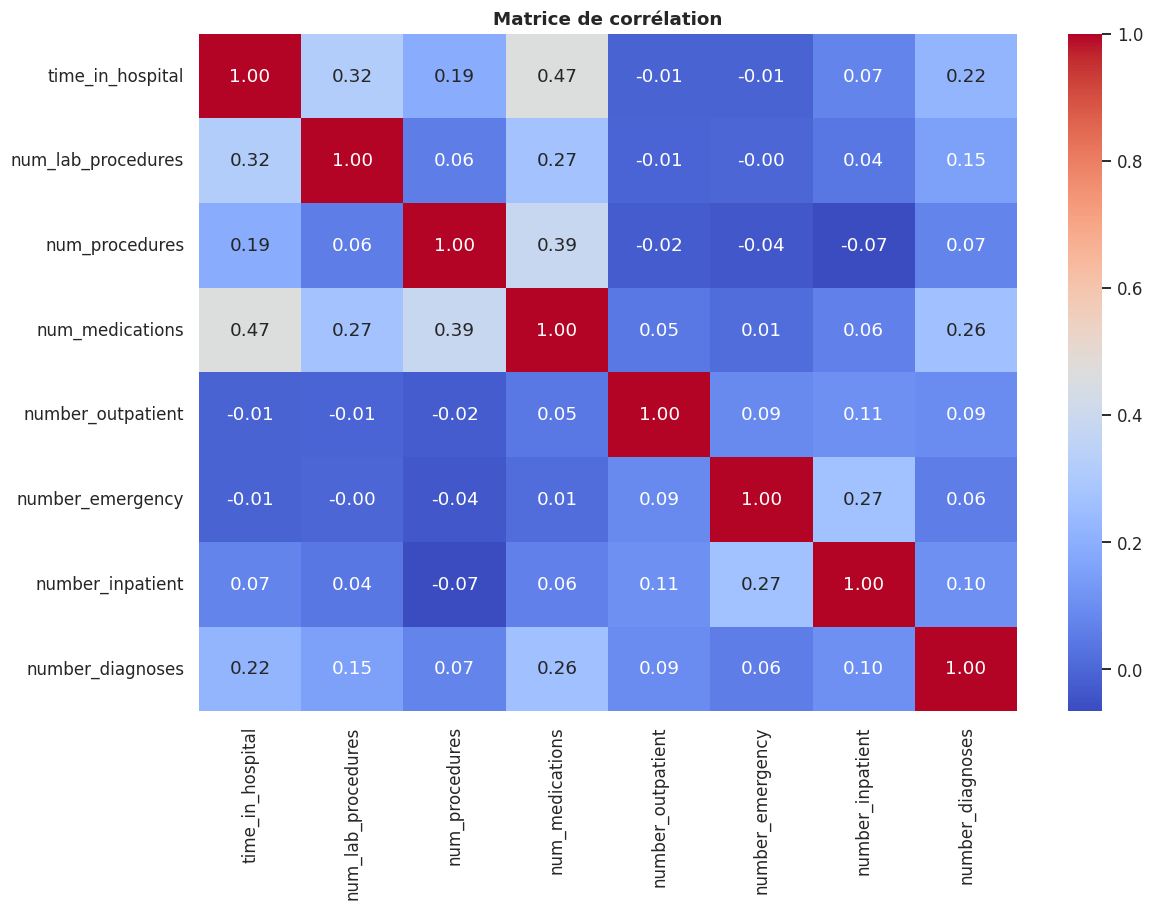

In [ ]:
# Matrice de corrélation

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matrice de corrélation")

plt.show()

## 2.12 Identification des problèmes de Data Quality

Après l'exploration initiale, plusieurs problèmes potentiels ont été
identifiés :

### 1. Valeurs manquantes

Certaines variables contiennent des valeurs manquantes ou le symbole `?`.

### 2. Variables catégorielles

Plusieurs variables sont catégorielles et devront être transformées
avant leur utilisation dans certains algorithmes.

### 3. Variables numériques

Les variables numériques présentent des distributions différentes et
certaines peuvent être fortement asymétriques.

### 4. Valeurs aberrantes

Certaines observations peuvent présenter des valeurs extrêmes qui
devront être analysées.

### 5. Variables d'identification

`encounter_id` et `patient_nbr` sont des identifiants et ne doivent pas
être considérés comme des caractéristiques médicales classiques.

### 6. Répétition des patients

Un même patient peut apparaître dans plusieurs séjours hospitaliers.
Cette situation doit être prise en compte afin d'éviter une fuite
d'information entre les ensembles d'entraînement et de test.

### 7. Déséquilibre de la variable cible

La réadmission dans les 30 jours est une classe minoritaire.

Ces différents problèmes seront traités dans l'étape suivante :
**Data Preparation**.

# 3. Data Preparation

Après avoir identifié les principaux problèmes de qualité des données, nous
passons à la préparation du dataset.

Cette étape consiste à traiter les valeurs manquantes, analyser les variables
problématiques et préparer progressivement les données pour les étapes de
segmentation et de classification.

Afin de conserver les données originales intactes, une copie du DataFrame
sera utilisée pour toutes les transformations.

In [18]:
# Création d'une copie du dataset original
df_clean = df.copy()

print("Dimensions du dataset :", df_clean.shape)

Dimensions du dataset : (101766, 50)


## 3.1 Traitement des valeurs manquantes

Lors de l'exploration des données, nous avons constaté que certaines valeurs
manquantes sont représentées par le symbole `?`.

Ce symbole n'est pas automatiquement reconnu comme une valeur manquante par
Pandas.

Nous allons donc remplacer les `?` par `NaN` afin de pouvoir identifier et
traiter correctement les valeurs manquantes.

In [19]:
import numpy as np

# Remplacement des "?" par NaN
df_clean.replace("?", np.nan, inplace=True)

print("Les '?' ont été remplacés par NaN.")

Les '?' ont été remplacés par NaN.


### 3.1.1 Analyse des valeurs manquantes après conversion

Après avoir remplacé les `?` par `NaN`, nous calculons le nombre et le
pourcentage de valeurs manquantes pour chaque variable.

Cette analyse permettra de déterminer les stratégies de traitement adaptées
à chaque variable.

In [20]:
# Nombre de valeurs manquantes
missing_count = df_clean.isnull().sum()

# Pourcentage de valeurs manquantes
missing_percent = (missing_count / len(df_clean)) * 100

# Création d'un tableau récapitulatif
missing_table = pd.DataFrame({
    "Valeurs_manquantes": missing_count,
    "Pourcentage": missing_percent
})

# Garder uniquement les colonnes ayant des valeurs manquantes
missing_table = missing_table[
    missing_table["Valeurs_manquantes"] > 0
]

# Trier de la plus forte proportion à la plus faible
missing_table = missing_table.sort_values(
    by="Pourcentage",
    ascending=False
)

missing_table

,Valeurs_manquantes,Pourcentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


### 3.1.2 Analyse des variables fortement incomplètes

L'analyse des valeurs manquantes montre que certaines variables présentent
un taux élevé de données manquantes.

Cependant, un taux élevé de valeurs manquantes ne signifie pas automatiquement
que la variable doit être supprimée. La décision dépend également de la
signification de la variable et de son intérêt pour l'analyse.

Nous examinons donc séparément les variables les plus concernées.

In [21]:
for col in ["diag_1", "diag_2", "diag_3"]:
    print(f"\n{col}")
    print("Valeurs manquantes :", df_clean[col].isnull().sum())
    print("Nombre de modalités :", df_clean[col].nunique())
    print(df_clean[col].value_counts().head(10))


diag_1
Valeurs manquantes : 21
Nombre de modalités : 716
diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028
Name: count, dtype: int64

diag_2
Valeurs manquantes : 358
Nombre de modalités : 748
diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
496    3305
599    3288
403    2823
414    2650
411    2566
Name: count, dtype: int64

diag_3
Valeurs manquantes : 1423
Nombre de modalités : 789
diag_3
250    11555
401     8289
276     5175
428     4577
427     3955
414     3664
496     2605
403     2357
585     1992
272     1969
Name: count, dtype: int64


### 3.1.3 Traitement des valeurs manquantes des diagnostics

Les variables `diag_1`, `diag_2` et `diag_3` présentent relativement peu
de valeurs manquantes par rapport à la taille totale du dataset.

Afin de conserver les séjours concernés et d'éviter de supprimer des
observations pour lesquelles seule l'information diagnostique est absente,
les valeurs manquantes sont remplacées par la catégorie `Unknown`.

Le nombre élevé de modalités observé dans ces variables sera traité
ultérieurement lors de la préparation des variables pour les modèles.

In [22]:
diagnosis_columns = ["diag_1", "diag_2", "diag_3"]

for col in diagnosis_columns:
    df_clean[col] = df_clean[col].fillna("Unknown")

# Vérification
df_clean[diagnosis_columns].isnull().sum()

,0
diag_1,0
diag_2,0
diag_3,0


### 3.1.4 Traitement de la variable `race`

La variable `race` présente environ 2,23 % de valeurs manquantes.

Afin de conserver les observations concernées sans attribuer artificiellement
une catégorie existante, les valeurs manquantes sont remplacées par la
catégorie `Unknown`.

In [23]:
df_clean["race"] = df_clean["race"].fillna("Unknown")

# Vérification
print(df_clean["race"].value_counts(dropna=False))
print("\nValeurs manquantes :", df_clean["race"].isnull().sum())

race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

Valeurs manquantes : 0


### 3.1.5 Traitement de la variable `weight`

La variable `weight` présente environ 96,86 % de valeurs manquantes.

La proportion de valeurs disponibles étant très faible, cette variable
ne peut pas être exploitée de manière fiable sur l'ensemble du dataset.

Nous décidons donc de supprimer `weight` du jeu de données préparé.

In [24]:
df_clean.drop(columns=["weight"], inplace=True)

print("Variable 'weight' supprimée.")
print("Dimensions :", df_clean.shape)

Variable 'weight' supprimée.
Dimensions : (101766, 49)


### 3.1.6 Traitement de `max_glu_serum` et `A1Cresult`

Les variables `max_glu_serum` et `A1Cresult` présentent une proportion
importante de valeurs manquantes.

Contrairement à `weight`, ces variables correspondent à des résultats
d'examens. Nous choisissons donc de conserver l'information sur l'absence
de résultat en créant une catégorie `Not measured`.

Cette approche permet de conserver les deux variables sans imputer
artificiellement un résultat médical.

In [25]:
df_clean["max_glu_serum"] = df_clean["max_glu_serum"].fillna("Not measured")
df_clean["A1Cresult"] = df_clean["A1Cresult"].fillna("Not measured")

print("max_glu_serum :")
print(df_clean["max_glu_serum"].value_counts(dropna=False))

print("\nA1Cresult :")
print(df_clean["A1Cresult"].value_counts(dropna=False))

max_glu_serum :
max_glu_serum
Not measured    96420
Norm             2597
>200             1485
>300             1264
Name: count, dtype: int64

A1Cresult :
A1Cresult
Not measured    84748
>8               8216
Norm             4990
>7               3812
Name: count, dtype: int64


### 3.1.7 Traitement de `medical_specialty`

La variable `medical_specialty` présente environ 49 % de valeurs manquantes.

La spécialité médicale peut néanmoins apporter une information utile.
Nous choisissons donc de conserver cette variable et de remplacer les
valeurs manquantes par la catégorie `Unknown`.

In [26]:
df_clean["medical_specialty"] = (
    df_clean["medical_specialty"].fillna("Unknown")
)

print(df_clean["medical_specialty"].value_counts().head(15))

medical_specialty
Unknown                            49949
InternalMedicine                   14635
Emergency/Trauma                    7565
Family/GeneralPractice              7440
Cardiology                          5352
Surgery-General                     3099
Nephrology                          1613
Orthopedics                         1400
Orthopedics-Reconstructive          1233
Radiologist                         1140
Pulmonology                          871
Psychiatry                           854
Urology                              685
ObstetricsandGynecology              671
Surgery-Cardiovascular/Thoracic      652
Name: count, dtype: int64


In [27]:
print("Nombre de modalités :", df_clean["payer_code"].nunique())

print("\nDistribution :")
print(df_clean["payer_code"].value_counts(dropna=False))

Nombre de modalités : 17

Distribution :
payer_code
NaN    40256
MC     32439
HM      6274
SP      5007
BC      4655
MD      3532
CP      2533
UN      2448
CM      1937
OG      1033
PO       592
DM       549
CH       146
WC       135
OT        95
MP        79
SI        55
FR         1
Name: count, dtype: int64


### 3.1.8 Traitement de la variable `payer_code`

La variable `payer_code` présente environ 39,6 % de valeurs manquantes et
17 modalités observées.

Compte tenu de la nature catégorielle de cette variable, une imputation
prédictive pourrait attribuer artificiellement un type de payeur sans
garantie que cette catégorie corresponde à la valeur réelle.

Nous choisissons donc de conserver la variable et de représenter les valeurs
manquantes par une catégorie `Unknown`. Cette stratégie permet de conserver
les observations tout en distinguant explicitement l'absence d'information.

In [28]:
# Remplacement des valeurs manquantes de payer_code
df_clean["payer_code"] = df_clean["payer_code"].fillna("Unknown")

# Vérification
print(df_clean["payer_code"].value_counts(dropna=False))

payer_code
Unknown    40256
MC         32439
HM          6274
SP          5007
BC          4655
MD          3532
CP          2533
UN          2448
CM          1937
OG          1033
PO           592
DM           549
CH           146
WC           135
OT            95
MP            79
SI            55
FR             1
Name: count, dtype: int64


### 3.1.9 Vérification finale des valeurs manquantes

Après avoir appliqué les différentes stratégies de traitement, nous vérifions
de nouveau la présence de valeurs manquantes dans le dataset.

Cette vérification permet de s'assurer que les traitements ont été correctement
appliqués et d'identifier d'éventuelles variables nécessitant encore une
intervention.

In [29]:
# Vérification des valeurs manquantes restantes
missing_after = df_clean.isnull().sum()

missing_after = missing_after[
    missing_after > 0
].sort_values(ascending=False)

print("Valeurs manquantes restantes :")
print(missing_after)

Valeurs manquantes restantes :
Series([], dtype: int64)


## 3.2 Analyse des identifiants et des séjours multiples

Le dataset contient deux variables d'identification :

- `encounter_id` : identifiant unique d'un séjour hospitalier ;
- `patient_nbr` : identifiant unique d'un patient.

Un même patient peut apparaître plusieurs fois dans le dataset s'il a effectué
plusieurs séjours hospitaliers.

Nous allons donc analyser le nombre de séjours et le nombre de patients uniques,
ainsi que la fréquence des séjours multiples par patient.

Cette analyse est importante pour éviter qu'un même patient apparaisse à la fois
dans les données d'entraînement et dans les données de test lors de la phase de
modélisation.

In [30]:
# Nombre de séjours et de patients uniques

n_encounters = df_clean["encounter_id"].nunique()
n_patients = df_clean["patient_nbr"].nunique()

print("Nombre total de lignes :", len(df_clean))
print("Nombre de séjours uniques :", n_encounters)
print("Nombre de patients uniques :", n_patients)

Nombre total de lignes : 101766
Nombre de séjours uniques : 101766
Nombre de patients uniques : 71518


### 3.2.1 Analyse du nombre de séjours par patient

Le dataset contient 101 766 séjours hospitaliers correspondant à
71 518 patients uniques.

Cette différence confirme qu'un même patient peut apparaître dans plusieurs
séjours hospitaliers.

Nous analysons donc le nombre de séjours par patient afin de mesurer
l'importance de ces répétitions avant de définir la stratégie de préparation
des données pour la modélisation.

In [32]:
# Nombre de séjours par patient
visits_per_patient = df_clean.groupby("patient_nbr").size()

print("Patients avec un seul séjour :",
      (visits_per_patient == 1).sum())

print("Patients avec plusieurs séjours :",
      (visits_per_patient > 1).sum())

print("\nStatistiques du nombre de séjours par patient :")
print(visits_per_patient.describe())

Patients avec un seul séjour : 54745
Patients avec plusieurs séjours : 16773

Statistiques du nombre de séjours par patient :
count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
dtype: float64


### 3.2.2 Gestion des patients avec plusieurs séjours

L'analyse montre qu'un même patient peut être associé à plusieurs séjours
hospitaliers.

Nous choisissons de conserver ces différents séjours car ils représentent
des événements hospitaliers distincts et contiennent des informations utiles.

Cependant, lors de la séparation des données en ensembles d'entraînement et
de test, les séjours appartenant à un même patient devront rester dans le
même ensemble.

Cette stratégie permettra de limiter le risque de fuite d'information entre
les données d'entraînement et de test.

In [33]:
# Vérification du nombre de séjours par patient
visits_per_patient = df_clean.groupby("patient_nbr").size()

# Nombre de patients avec un seul séjour
single_visit = (visits_per_patient == 1).sum()

# Nombre de patients avec plusieurs séjours
multiple_visits = (visits_per_patient > 1).sum()

print("Patients avec un seul séjour :", single_visit)
print("Patients avec plusieurs séjours :", multiple_visits)

# Vérification : aucune ligne n'est supprimée à cette étape
print("\nNombre de séjours conservés :", len(df_clean))

Patients avec un seul séjour : 54745
Patients avec plusieurs séjours : 16773

Nombre de séjours conservés : 101766


### 3.2.3 Traitement des variables d'identification

Les variables `encounter_id` et `patient_nbr` sont des identifiants et ne
constituent pas des caractéristiques cliniques à utiliser directement par
les modèles.

`encounter_id` identifie uniquement chaque séjour hospitalier. Il peut donc
être supprimé du jeu de données préparé.

`patient_nbr` identifie le patient. Cette variable sera conservée temporairement
afin de permettre ultérieurement une séparation des données par patient et
d'éviter qu'un même patient apparaisse à la fois dans les ensembles
d'entraînement et de test.

`patient_nbr` ne sera cependant pas utilisé comme variable explicative par
les modèles.

In [34]:
# Suppression de l'identifiant du séjour
df_clean.drop(columns=["encounter_id"], inplace=True)

# Vérification
print("Dimensions après suppression de encounter_id :", df_clean.shape)

print("\nencounter_id présent :",
      "encounter_id" in df_clean.columns)

print("patient_nbr présent :",
      "patient_nbr" in df_clean.columns)

Dimensions après suppression de encounter_id : (101766, 48)

encounter_id présent : False
patient_nbr présent : True


## 3.3 Analyse des variables catégorielles

Le dataset contient plusieurs variables catégorielles qui devront être
transformées avant leur utilisation par certains algorithmes de Machine Learning.

Cependant, toutes les variables catégorielles ne peuvent pas être traitées de
la même manière. Certaines possèdent peu de modalités, tandis que d'autres,
comme les variables de diagnostic, peuvent contenir plusieurs centaines de
catégories.

Nous commençons donc par identifier les variables catégorielles et analyser
leur cardinalité, c'est-à-dire le nombre de modalités différentes présentes
dans chaque variable.

In [35]:
# Identification des variables catégorielles
categorical_columns = df_clean.select_dtypes(
    include=["object"]
).columns.tolist()

print("Nombre de variables catégorielles :", len(categorical_columns))

print("\nVariables catégorielles :")
for col in categorical_columns:
    print("-", col)

Nombre de variables catégorielles : 36

Variables catégorielles :
- race
- gender
- age
- payer_code
- medical_specialty
- diag_1
- diag_2
- diag_3
- max_glu_serum
- A1Cresult
- metformin
- repaglinide
- nateglinide
- chlorpropamide
- glimepiride
- acetohexamide
- glipizide
- glyburide
- tolbutamide
- pioglitazone
- rosiglitazone
- acarbose
- miglitol
- troglitazone
- tolazamide
- examide
- citoglipton
- insulin
- glyburide-metformin
- glipizide-metformin
- glimepiride-pioglitazone
- metformin-rosiglitazone
- metformin-pioglitazone
- change
- diabetesMed
- readmitted


### 3.3.1 Analyse de la cardinalité des variables catégorielles

Le nombre de modalités d'une variable catégorielle influence la stratégie
d'encodage à utiliser.

Les variables ayant peu de modalités peuvent généralement être encodées
directement, tandis que les variables à forte cardinalité nécessitent une
attention particulière afin d'éviter la création d'un nombre excessif de
variables après encodage.

Nous calculons donc le nombre de modalités de chaque variable catégorielle.

In [36]:
# Calcul du nombre de modalités par variable catégorielle
cardinality = (
    df_clean[categorical_columns]
    .nunique()
    .sort_values(ascending=False)
)

cardinality

,0
diag_3,790
diag_2,749
diag_1,717
medical_specialty,73
payer_code,18
age,10
race,6
glyburide-metformin,4
max_glu_serum,4
A1Cresult,4


### 3.3.2 Identification des variables à forte cardinalité

Les variables possédant un grand nombre de modalités nécessitent un traitement
spécifique avant leur utilisation dans les modèles.

Un encodage direct de ces variables pourrait générer un très grand nombre
de nouvelles colonnes.

Nous distinguons donc les variables à faible cardinalité des variables à
forte cardinalité avant de choisir les stratégies d'encodage.

In [37]:
# Seuil utilisé pour explorer la cardinalité
threshold = 20

low_cardinality = cardinality[cardinality <= threshold]
high_cardinality = cardinality[cardinality > threshold]

print("=== Variables à faible cardinalité ===")
print(low_cardinality)

print("\n=== Variables à forte cardinalité ===")
print(high_cardinality)

=== Variables à faible cardinalité ===
payer_code                  18
age                         10
race                         6
glyburide-metformin          4
max_glu_serum                4
A1Cresult                    4
metformin                    4
repaglinide                  4
nateglinide                  4
chlorpropamide               4
glimepiride                  4
glipizide                    4
pioglitazone                 4
glyburide                    4
acarbose                     4
rosiglitazone                4
miglitol                     4
insulin                      4
gender                       3
tolazamide                   3
readmitted                   3
acetohexamide                2
tolbutamide                  2
troglitazone                 2
metformin-rosiglitazone      2
metformin-pioglitazone       2
glimepiride-pioglitazone     2
glipizide-metformin          2
change                       2
diabetesMed                  2
citoglipton                  1


### 3.3.3 Identification et suppression des variables constantes

L'analyse de la cardinalité montre que les variables `examide` et
`citoglipton` ne possèdent qu'une seule modalité dans l'ensemble du dataset.

Une variable constante ne permet pas de différencier les observations et
n'apporte donc aucune information discriminante pour la segmentation ou
la classification.

Ces deux variables sont supprimées du jeu de données préparé.

In [39]:
for col in ["examide", "citoglipton"]:
    print(f"{col} :")
    print(df_clean[col].value_counts(dropna=False))
    print()

examide :
examide
No    101766
Name: count, dtype: int64

citoglipton :
citoglipton
No    101766
Name: count, dtype: int64



In [40]:
df_clean.drop(
    columns=["examide", "citoglipton"],
    inplace=True
)

print("Dimensions après suppression :", df_clean.shape)

Dimensions après suppression : (101766, 46)


### 3.3.4 Regroupement des codes de diagnostic

Les variables `diag_1`, `diag_2` et `diag_3` présentent une très forte
cardinalité, avec plusieurs centaines de codes différents.

Un encodage direct de ces codes générerait un nombre très important de
variables.

Afin de réduire cette cardinalité et d'obtenir des variables plus
interprétables, les codes de diagnostic seront regroupés en grandes
catégories.

Les variables originales seront conservées temporairement afin de vérifier
la transformation avant leur suppression.

In [41]:
for col in ["diag_1", "diag_2", "diag_3"]:
    print(f"\n--- {col} ---")
    print(df_clean[col].astype(str).head(20).tolist())


--- diag_1 ---
['250.83', '276', '648', '8', '197', '414', '414', '428', '398', '434', '250.7', '157', '428', '428', '518', '999', '410', '682', '402', '737']

--- diag_2 ---
['Unknown', '250.01', '250', '250.43', '157', '411', '411', '492', '427', '198', '403', '288', '250.43', '411', '998', '507', '411', '174', '425', '427']

--- diag_3 ---
['Unknown', '255', 'V27', '403', '250', '250', 'V45', '250', '38', '486', '996', '197', '250.6', '427', '627', '996', '414', '250', '416', '714']


### 3.3.5 Création de catégories de diagnostic

Les codes de diagnostic sont regroupés en catégories plus générales afin
de réduire le nombre de modalités.

Cette transformation permet de conserver l'information clinique principale
tout en obtenant une représentation plus adaptée aux algorithmes de Machine
Learning.

In [42]:
def categorize_diagnosis(code):

    # Valeur manquante déjà transformée précédemment
    if code == "Unknown":
        return "Unknown"

    code = str(code)

    # Codes commençant par V ou E
    if code.startswith("V") or code.startswith("E"):
        return "Other"

    try:
        code = float(code)
    except ValueError:
        return "Other"

    # Diabète
    if 250 <= code < 251:
        return "Diabetes"

    # Circulatoire
    elif 390 <= code <= 459 or code == 785:
        return "Circulatory"

    # Respiratoire
    elif 460 <= code <= 519 or code == 786:
        return "Respiratory"

    # Digestif
    elif 520 <= code <= 579 or code == 787:
        return "Digestive"

    # Blessures / empoisonnements
    elif 800 <= code <= 999:
        return "Injury"

    # Musculosquelettique
    elif 710 <= code <= 739:
        return "Musculoskeletal"

    # Génito-urinaire
    elif 580 <= code <= 629 or code == 788:
        return "Genitourinary"

    # Néoplasmes
    elif 140 <= code <= 239:
        return "Neoplasms"

    else:
        return "Other"

In [43]:
for col in ["diag_1", "diag_2", "diag_3"]:
    df_clean[col + "_group"] = df_clean[col].apply(categorize_diagnosis)

In [44]:
for col in ["diag_1_group", "diag_2_group", "diag_3_group"]:
    print(f"\n{col}")
    print(df_clean[col].value_counts())


diag_1_group
diag_1_group
Circulatory        30437
Other              18172
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Unknown               21
Name: count, dtype: int64

diag_2_group
diag_2_group
Circulatory        31881
Other              26553
Diabetes           12794
Respiratory        10895
Genitourinary       8376
Digestive           4170
Neoplasms           2547
Injury              2428
Musculoskeletal     1764
Unknown              358
Name: count, dtype: int64

diag_3_group
diag_3_group
Circulatory        30306
Other              29195
Diabetes           17157
Respiratory         7358
Genitourinary       6680
Digestive           3930
Injury              1946
Musculoskeletal     1915
Neoplasms           1856
Unknown             1423
Name: count, dtype: int64


### 3.3.6 Suppression des variables de diagnostic originales

Les variables `diag_1`, `diag_2` et `diag_3` ont été regroupées en catégories
de diagnostic plus générales.

Les nouvelles variables `diag_1_group`, `diag_2_group` et `diag_3_group`
conservent ainsi une information clinique plus synthétique tout en réduisant
fortement la cardinalité.

Les variables de diagnostic originales sont donc supprimées afin d'éviter
la redondance et la création d'un nombre trop important de variables lors
de l'encodage.

In [45]:
df_clean.drop(
    columns=["diag_1", "diag_2", "diag_3"],
    inplace=True
)

print("Dimensions après suppression :", df_clean.shape)

print("\nNouvelles variables de diagnostic :")
print([
    col for col in df_clean.columns
    if "diag" in col
])

Dimensions après suppression : (101766, 46)

Nouvelles variables de diagnostic :
['number_diagnoses', 'diag_1_group', 'diag_2_group', 'diag_3_group']


### 3.3.7 Analyse de la variable `medical_specialty`

La variable `medical_specialty` possède 73 modalités différentes.

Certaines spécialités peuvent être très peu représentées dans le dataset.
La conservation de toutes ces modalités lors de l'encodage pourrait augmenter
inutilement le nombre de variables.

Nous analysons donc leur fréquence afin d'identifier les spécialités les plus
fréquentes et les catégories rares.

In [46]:
specialty_counts = df_clean["medical_specialty"].value_counts()

print("Nombre de spécialités :", df_clean["medical_specialty"].nunique())

print("\nFréquence des spécialités :")
print(specialty_counts.to_string())

Nombre de spécialités : 73

Fréquence des spécialités :
medical_specialty
Unknown                                 49949
InternalMedicine                        14635
Emergency/Trauma                         7565
Family/GeneralPractice                   7440
Cardiology                               5352
Surgery-General                          3099
Nephrology                               1613
Orthopedics                              1400
Orthopedics-Reconstructive               1233
Radiologist                              1140
Pulmonology                               871
Psychiatry                                854
Urology                                   685
ObstetricsandGynecology                   671
Surgery-Cardiovascular/Thoracic           652
Gastroenterology                          564
Surgery-Vascular                          533
Surgery-Neuro                             468
PhysicalMedicineandRehabilitation         391
Oncology                                  348
Pediat

### 3.3.8 Regroupement des spécialités médicales rares

L'analyse de `medical_specialty` montre une forte concentration des observations
dans quelques spécialités, tandis que de nombreuses modalités sont très peu
représentées.

Afin de limiter la cardinalité et d'éviter la création de nombreuses variables
très rares lors de l'encodage, les spécialités représentant moins de 0,1 %
des observations sont regroupées dans une catégorie `Other`.

La catégorie `Unknown` est conservée séparément car elle représente les
observations pour lesquelles la spécialité médicale n'est pas renseignée.

In [47]:
# Seuil : 0,1 % du nombre total d'observations
threshold_specialty = 0.001 * len(df_clean)

print("Seuil de fréquence :", threshold_specialty)

# Fréquence de chaque spécialité
specialty_counts = df_clean["medical_specialty"].value_counts()

# Spécialités considérées comme rares
rare_specialties = specialty_counts[
    specialty_counts < threshold_specialty
].index

print("Nombre de spécialités rares :", len(rare_specialties))

Seuil de fréquence : 101.766
Nombre de spécialités rares : 46


In [48]:
df_clean["medical_specialty_group"] = (
    df_clean["medical_specialty"]
    .where(~df_clean["medical_specialty"].isin(rare_specialties), "Other")
)

print(
    df_clean["medical_specialty_group"]
    .value_counts()
    .to_string()
)

print(
    "\nNombre de modalités après regroupement :",
    df_clean["medical_specialty_group"].nunique()
)

medical_specialty_group
Unknown                              49949
InternalMedicine                     14635
Emergency/Trauma                      7565
Family/GeneralPractice                7440
Cardiology                            5352
Surgery-General                       3099
Nephrology                            1613
Orthopedics                           1400
Orthopedics-Reconstructive            1233
Radiologist                           1140
Other                                 1126
Pulmonology                            871
Psychiatry                             854
Urology                                685
ObstetricsandGynecology                671
Surgery-Cardiovascular/Thoracic        652
Gastroenterology                       564
Surgery-Vascular                       533
Surgery-Neuro                          468
PhysicalMedicineandRehabilitation      391
Oncology                               348
Pediatrics                             254
Hematology/Oncology           

In [49]:
print("Avant regroupement :",
      df_clean["medical_specialty"].nunique())

print("Après regroupement :",
      df_clean["medical_specialty_group"].nunique())

Avant regroupement : 73
Après regroupement : 28


### 3.3.9 Finalisation du traitement de `medical_specialty`

Après regroupement des spécialités médicales rares, le nombre de modalités
de `medical_specialty` est passé de 73 à 28.

Les 46 spécialités représentant moins de 0,1 % des observations ont été
regroupées dans la catégorie `Other`.

La variable originale `medical_specialty` est maintenant supprimée et
remplacée par `medical_specialty_group`.

In [50]:
df_clean.drop(columns=["medical_specialty"], inplace=True)

print("medical_specialty présent :",
      "medical_specialty" in df_clean.columns)

print("medical_specialty_group présent :",
      "medical_specialty_group" in df_clean.columns)

print("Dimensions :", df_clean.shape)

medical_specialty présent : False
medical_specialty_group présent : True
Dimensions : (101766, 46)
